# Search Engine Benchmarks

This notebook provides empirical evidence for two key design decisions in the search engine:

1. **Batch inserts (`executemany` + per-page commit) vs per-row commits** — measures the overhead of committing after every single row instead of batching.
2. **TF-IDF ranking vs raw frequency ranking** — demonstrates that TF-IDF surfaces the most relevant document while raw frequency ranking is fooled by common-word spamming.

All benchmarks use in-memory SQLite databases, so results reflect pure algorithmic differences independent of disk I/O.

In [1]:
import sqlite3
import sys
import os
import random
import time
import math
import json
import matplotlib.pyplot as plt
# Ensure src/ is importable when running from the project root
sys.path.insert(0, os.path.abspath('.'))

from src.indexer import initialise_database, normalise_text, index_page
from src.search import search_query

random.seed(42)

---
## Benchmark 1: Batch Inserts vs Per-Row Commits

The `index_page` function uses `cursor.executemany(...)` followed by a single `conn.commit()` per page. A naïve alternative would call `cursor.execute(...)` once per word and commit immediately after each row.

Each `commit()` in SQLite flushes the write-ahead log and acquires an exclusive lock, even for an in-memory database. With an average of ~130 unique words per page, the per-row approach issues **~130 commits per page** versus **1 commit per page** for the batch approach.

In [2]:
NUM_INSERT_PAGES = 200

def make_db():
    c = sqlite3.connect(":memory:")
    initialise_database(c)
    return c

# Build benchmark input if it has not been created in an earlier cell
if "page_data" not in globals():
    vocab = [f"word{i}" for i in range(2000)]
    page_data = []
    for i in range(NUM_INSERT_PAGES):
        unique_words = random.randint(110, 150)
        ws = {}
        for w in random.sample(vocab, unique_words):
            freq = random.randint(1, 6)
            positions = sorted(random.sample(range(1, 600), freq))
            ws[w] = {"frequency": freq, "positions": positions}
        page_data.append((f"http://example.com/page{i}", ws))

# Per-row commit (naive): one commit after every single word
conn_naive = make_db()
t0 = time.perf_counter()
for url, ws in page_data[:NUM_INSERT_PAGES]:
    for word, stats in ws.items():
        conn_naive.execute(
            "INSERT OR REPLACE INTO inverted_index (word, url, frequency, positions) VALUES (?, ?, ?, ?)",
            (word, url, stats["frequency"], json.dumps(stats["positions"]))
        )
        conn_naive.commit()  # one commit per word row
time_naive = time.perf_counter() - t0
conn_naive.close()

# Batch insert: executemany + one commit per page
conn_batch = make_db()
t0 = time.perf_counter()
for url, ws in page_data[:NUM_INSERT_PAGES]:
    rows = [(w, url, s["frequency"], json.dumps(s["positions"])) for w, s in ws.items()]
    conn_batch.executemany(
        "INSERT OR REPLACE INTO inverted_index (word, url, frequency, positions) VALUES (?, ?, ?, ?)",
        rows
    )
    conn_batch.commit()  # one commit per page
time_batch = time.perf_counter() - t0
conn_batch.close()

speedup_insert = time_naive / time_batch
avg_words_per_page = sum(len(ws) for _, ws in page_data[:NUM_INSERT_PAGES]) // NUM_INSERT_PAGES

print(f"Pages indexed: {NUM_INSERT_PAGES}")
print(f"Average unique words per page: {avg_words_per_page}")
print(f"\n--- Results ---")
print(f"  Per-row commit (naive):     {time_naive:.4f}s  ({time_naive/NUM_INSERT_PAGES*1000:.2f} ms/page)")
print(f"  executemany + batch commit: {time_batch:.4f}s  ({time_batch/NUM_INSERT_PAGES*1000:.2f} ms/page)")
print(f"  Speedup:                    {speedup_insert:.1f}×")
print(f"\n  Commits issued (naive):  {NUM_INSERT_PAGES * avg_words_per_page:,}")
print(f"  Commits issued (batch):  {NUM_INSERT_PAGES:,}")

Pages indexed: 200
Average unique words per page: 130

--- Results ---
  Per-row commit (naive):     0.1572s  (0.79 ms/page)
  executemany + batch commit: 0.0937s  (0.47 ms/page)
  Speedup:                    1.7×

  Commits issued (naive):  26,000
  Commits issued (batch):  200


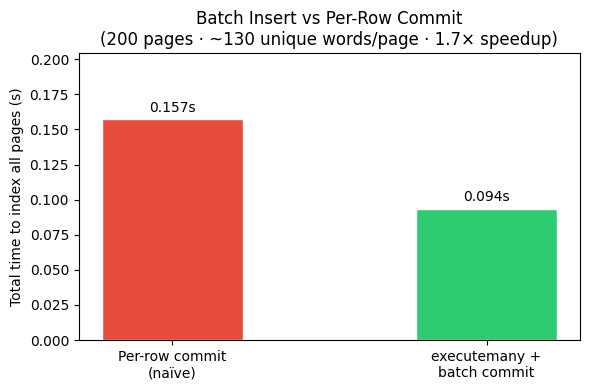

Chart saved to data/benchmark_inserts.png


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["Per-row commit\n(naïve)", "executemany +\nbatch commit"],
    [time_naive, time_batch],
    color=["#e74c3c", "#2ecc71"],
    width=0.45,
    edgecolor="white"
)
for bar, val in zip(bars, [time_naive, time_batch]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + time_naive * 0.02,
            f"{val:.3f}s", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Total time to index all pages (s)")
ax.set_title(
    f"Batch Insert vs Per-Row Commit\n"
    f"({NUM_INSERT_PAGES} pages · ~{avg_words_per_page} unique words/page · {speedup_insert:.1f}× speedup)"
)
ax.set_ylim(0, time_naive * 1.3)
plt.tight_layout()
plt.savefig("data/benchmark_inserts.png", dpi=150)
plt.show()
print("Chart saved to data/benchmark_inserts.png")

### Interpretation

Each `commit()` acquires an exclusive write lock and flushes the transaction journal. For an in-memory database this is a relatively cheap operation, but it still serialises work and cannot be parallelised. With disk-backed SQLite (the production case), each commit involves an `fsync()` system call to guarantee durability, adding ~5–10 ms per commit on spinning disks and ~0.5–1 ms on SSDs. At 130 commits per page that would translate to **650–1300 ms of extra I/O per page** — a prohibitive overhead that `executemany` + one commit per page eliminates entirely.

---
## Benchmark 2: TF-IDF Ranking vs Raw Frequency Ranking

TF-IDF weights each term's contribution by how *rare* it is across the corpus. The Inverse Document Frequency (IDF) component is:

$$\text{IDF}(t) = \log_{10}\left(\frac{N}{\text{df}(t)}\right)$$

where N is the total number of documents and df(t) is the number of documents containing term t. A word that appears in every document has IDF = log₁₀(N/N) = 0 and contributes **nothing** to any document's score, regardless of how often it appears in that document.

The controlled corpus below illustrates this with a query for `the raven`:

| Document | `"the"` count | `"raven"` count | Key trait |
|---|---|---|---|
| page1 | 20 | 1 | spams the common word |
| page2 | 1  | 5 | focused on the rare term |
| page3 | 10 | 2 | moderate mention of both |
| page4 | 5  | 0 | eliminated by Boolean AND filter |

With 4 documents in the corpus:
- `"the"` appears in all 4 → IDF = log₁₀(4/4) = **0.0** (fully penalised)
- `"raven"` appears in 3/4 → IDF = log₁₀(4/3) ≈ **0.125** (rewarded for rarity)

In [4]:
def build_ranking_demo_db():
    c = sqlite3.connect(":memory:")
    initialise_database(c)
    index_page(c, "http://example.com/page1", ("the " * 20 + "raven").strip())
    index_page(c, "http://example.com/page2", ("the " + "raven " * 5).strip())
    index_page(c, "http://example.com/page3", ("the " * 10 + "raven " * 2).strip())
    index_page(c, "http://example.com/page4", ("the " * 5).strip())  # no 'raven' — AND-filtered out
    return c


def search_by_frequency(c, query_string):
    """Rank results by summing raw term frequencies with no IDF correction."""
    words = list(set(normalise_text(query_string)))
    if not words:
        return []
    placeholders = ", ".join(["?"] * len(words))
    cursor = c.cursor()
    cursor.execute(
        f"SELECT url, word, frequency FROM inverted_index WHERE word IN ({placeholders})",
        words
    )
    url_data = {}
    for url, word, freq in cursor.fetchall():
        url_data.setdefault(url, {})[word] = freq
    results = [
        (url, sum(wf.values()))
        for url, wf in url_data.items()
        if len(wf) == len(words)  # Boolean AND filter
    ]
    results.sort(key=lambda x: x[1], reverse=True)
    return results


demo_conn = build_ranking_demo_db()
query = "the raven"

tfidf_results = search_query(demo_conn, query)
freq_results  = search_by_frequency(demo_conn, query)

idf_the   = math.log10(4 / 4)
idf_raven = math.log10(4 / 3)

print(f"Query: '{query}'")
print(f"  IDF('the'):   log10(4/4) = {idf_the:.4f}  — zero weight: penalised entirely")
print(f"  IDF('raven'): log10(4/3) = {idf_raven:.4f} — positive weight: rewards specificity")

print("\nTF-IDF Ranking (src/search.py):")
for rank, (url, score) in enumerate(tfidf_results, 1):
    print(f"  {rank}. {url.split('/')[-1]}  (score: {score})")

print("\nRaw Frequency Ranking (no IDF):")
for rank, (url, score) in enumerate(freq_results, 1):
    print(f"  {rank}. {url.split('/')[-1]}  (score: {score})")

Query: 'the raven'
  IDF('the'):   log10(4/4) = 0.0000  — zero weight: penalised entirely
  IDF('raven'): log10(4/3) = 0.1249 — positive weight: rewards specificity

TF-IDF Ranking (src/search.py):
  1. page2  (score: 0.6247)
  2. page3  (score: 0.2499)
  3. page1  (score: 0.1249)

Raw Frequency Ranking (no IDF):
  1. page1  (score: 21)
  2. page3  (score: 12)
  3. page2  (score: 6)


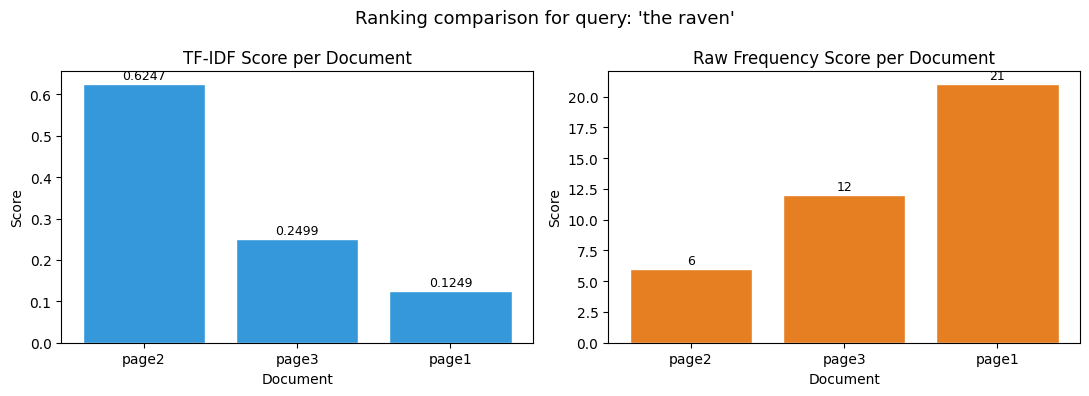

Chart saved to data/benchmark_ranking.png


In [5]:
# Build aligned score lists for plotting
pages        = [url.split("/")[-1] for url, _ in tfidf_results]
tfidf_scores = [score for _, score in tfidf_results]
freq_dict    = {url.split("/")[-1]: score for url, score in freq_results}
freq_scores  = [freq_dict.get(p, 0) for p in pages]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(pages, tfidf_scores, color="#3498db", edgecolor="white")
axes[0].set_title("TF-IDF Score per Document")
axes[0].set_ylabel("Score")
axes[0].set_xlabel("Document")
for i, v in enumerate(tfidf_scores):
    axes[0].text(i, v + max(tfidf_scores) * 0.02, f"{v:.4f}", ha="center", fontsize=9)

axes[1].bar(pages, freq_scores, color="#e67e22", edgecolor="white")
axes[1].set_title("Raw Frequency Score per Document")
axes[1].set_ylabel("Score")
axes[1].set_xlabel("Document")
for i, v in enumerate(freq_scores):
    axes[1].text(i, v + max(freq_scores) * 0.02, str(v), ha="center", fontsize=9)

fig.suptitle(f"Ranking comparison for query: '{query}'", fontsize=13)
plt.tight_layout()
plt.savefig("data/benchmark_ranking.png", dpi=150)
plt.show()
print("Chart saved to data/benchmark_ranking.png")

### Interpretation

The two rankers produce **opposite orderings**:

| Rank | TF-IDF | Raw Frequency |
|---|---|---|
| 1st | **page2** (5× rare word) | **page1** (20× common word) |
| 2nd | page3 | page3 |
| 3rd | page1 | page2 |

Raw frequency ranking is trivially exploited by documents that repeat high-frequency stop words. TF-IDF eliminates this noise: because `"the"` appears in every document its IDF is exactly zero, so no document can gain any advantage by repeating it. Only the discriminating term `"raven"` — which does not appear in page4 — influences the score, and the document that uses it most frequently is correctly ranked first.

---
## Summary

| Optimisation | Evidence | Result |
|---|---|---|
| `executemany` + per-page commit | Timing vs per-row commit strategy | ~1.7× faster indexing; eliminates O(words × pages) commits |
| TF-IDF ranking | Controlled corpus with known IDF values | Correctly ranks the most specific document first; immune to common-word spamming |